<a id='top'></a>


# CSCI3022 S23


# Homework 11: Modeling Using Regression
## Due Monday, May 1st at 11:59pm to Gradescope
Late Due Date:  Thursday, May 4th (last day of classes), 11:59pm MT
***

**Name**:Dominic Galgano

***

***
### Collaboration Policy

While completing the assignment you are not allowed to consult any source other than the course textbooks/online reference links provided on Canvas, your own class notes, and/or the posted lecture slides/in-class Jupyter notebooks.   You may discuss questions you have with your classmates or on Piazza or in office hours, but all work you submit must be your own, which means when writing up your solutions or code, you MUST do it entirely by yourself. 

You should be able to easily reproduce from scratch and explain a solution that was your own when asked in office hours by a TA/Instructor or on a quiz/exam without referencing your notes/book/HW.   


**Do not search/ask for a solution online**: You may not actively search for a solution to the problems below from the internet. This includes posting to or using sources like ChatGPT, StackOverflow, StackExchange, Reddit, Chegg, CourseHero, etc.  

**We are here to help!  Visit HW Hours and/or post questions on Piazza!**


Copying/consulting from the solution of another classmate or an online solution (or providing a classmate your solution) constitutes a **violation of the course's collaboration policy and the honor code and will result in an F in the course and a trip to the honor council**.   






### Instructions for Submitting in Correct Format 

You must submit a PDF of this Juptyer notebook to Gradescope by the deadline listed above.  Submissions that are not a PDF or that are not submitted to Gradescope will not be counted for credit.  

$\color{red}{\text{Before submitting your PDF, make sure that your LaTeX has rendered correctly in your PDF.}}$
$\color{red}{\text{Any of your solutions with incorrectly rendered or incompletely rendered LaTeX will be given 0 points.}}$ 

- There are several ways to quickly make a .pdf out of this notebook for Gradescope submission.  
 
 - If you are running Juptyer locally on your computer: 
 
     - Option1 : Select Kernel->Restart & Run All.  Then select File ->  Print Preview, and then Right-Click -> Print using your default browser and "Print to PDF"
 
     - Option 2: Select Kernel->Restart & Run All.   Then select File -> Download as PDF via LaTeX.  This will require your system path find a working install of a TeX compiler
 
 - If you are running using CSEL: 
 
     - Option1 :  Go to File ->Save & Export Notebook As-> HTML.  Then open the HTML, and then Right-Click -> Print and select "Print to PDF".  
     - Option2 :  Go to File ->Download. Then use this converter https://htmtopdf.herokuapp.com/ipynbviewer/ to convert ipynb to pdf.
 
### Notes
- For full points you must correctly match your questions to the respective Gradescope problem, and include clear comments in your code.   Please note that any LaTeX that is not correctly rendered in your submitted PDF will result in a 0 on the entire problem(s) that involves the unrendered LaTeX. 
- You **must show all work and justify ALL answers to receive credit**. Sparse or nonexistent work will receive sparse or nonexistent credit. 
- Any relevant data sets are available on Canvas. 
- LaTeX Tips:  Here is a [reference guide] (https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference).  **All** of your written commentary, justifications and mathematical work should be in Markdown.  I also recommend the [wikibook](https://en.wikibooks.org/wiki/LaTeX) for LaTex.
- Because you can technically evaluate notebook cells is a non-linear order, it's a good idea to do **Kernel $\rightarrow$ Restart & Run All** as a check before submitting your solutions.  
- It is **bad form** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code. 

- There is *not a prescribed API* for these problems.  You may answer coding questions with whatever syntax or object typing you deem fit.  Your evaluation will primarily live in the clarity of how well you present your final results, so don't skip over any interpretations!  Your code should still be commented and readable to ensure you followed the given course algorithm.




We'll need Numpy, Matplotlib, Pandas, and scipy.stats for this notebook, so let's load them. 


In [1]:
import numpy as np 
from scipy import stats
import statsmodels.api as sm 
import pandas as pd
import matplotlib.pylab as plt 
from scipy.stats import skew, kurtosis, norm
import seaborn
%matplotlib inline
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multicomp import MultiComparison
import random


For this entire assignment you are welcome to use any built-in methods/functions we have used in class.  If a built-in function/method outputs summary statistics or other useful output variables you can use that output directly when answering any questions below UNLESS otherwise specified in the problem (i.e. unless we tell you in the problem to write code to calculate a particular statistic from scratch based on its definition, you can just get that statistic/info from the output of a built-in method/function).

<a id='p1'></a>
# Problem 1 (15 pts)
***
Your friend owns a franchise business that sells and rents stand-up paddleboards.  
They have collected data from 95 of their shops and have asked you to create a model that predicts annual sales from their data.  The data is in the file `paddle.csv`

 ***Import the data set `paddle.csv`, and take a look at it.***

In [2]:
dfPad = pd.read_csv("paddle.csv")
dfPad.head()

,lakes,pop,advertising,competitors,sales
0,1,63,4.3,1,14.1
1,1,25,10.8,2,19.0
2,1,40,11.8,2,19.8
3,1,89,9.6,0,19.9
4,1,33,6.4,2,22.4


### Data Description:
The data file contains the following data for each of the 95 shops:

`lakes` -  The number of lakes or reservoirs within a 50 mile radius of the shop.

`pop` - Population density of the town where the shop is located (people per square mile).

`advertising` - The shop's annual amount spent on advertising/promotions (in thousands of dollars).

`competitors` - The number of competing stores within a 50 mile radius of the shop.

`sales` - The shop's annual net sales revenue (in thousands of dollars).

## Single-Predictor Regression



### [1] Part A) A naive model (8 pts)

Your friend says that since stand-up paddleboarding is a water activity, they would expect annual sales revenue to be dependent on the number of lakes/reservoirs in the region near a given shop.  

Your task: 
- ***(1A i) (2 points):  Make a simple linear regression (SLR) model with `sales` as the response, predicted by the variable `lakes`.***    

- ***Print the summary output for the model***

- ***Then write the equation for the model in a markdown cell.***



In [3]:
slr = sm.OLS(dfPad['sales'], sm.add_constant(dfPad['lakes'])).fit()
slr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     13.20
Date:                Tue, 02 May 2023   Prob (F-statistic):           0.000459
Time:                        04:37:33   Log-Likelihood:                -295.44
No. Observations:                  95   AIC:                             594.9
Df Residuals:                      93   BIC:                             600.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.6338      1.224     20.120      0.000      22.203      27.065
lakes         -0.9723      0.268     -3.633      0.000      -1.504      -0.441
==============================================================================
Omnibus:                        0.536   Durbin-Watson:                   0.905
Prob(Omnibus):                  0.765   Jarque-Bera (JB):                0.662
Skew:                           0.046   Prob(JB):                        0.718
Kurtosis:                       2.602   Cond. No.                         10.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$Y = 24.6338 - 0.9723x$

 - ***(1A ii) (2 points) Make the following 4 plots (described below).  
Title each plot and label your axes on each plot.*** 

  - ***Scatter plot of the data (i.e. lakes vs sales) and overlay the simple linear regression line you found above***.  

  - ***Frequency histogram of residuals of your SLR model.***  
  
  - ***A Q-Q plot of *residuals*, comparing to a normal distribution.***
  - ***Scatter plot where the lake data values are the x-axis and the model residuals are the y-axis.***


Figure(640x480)


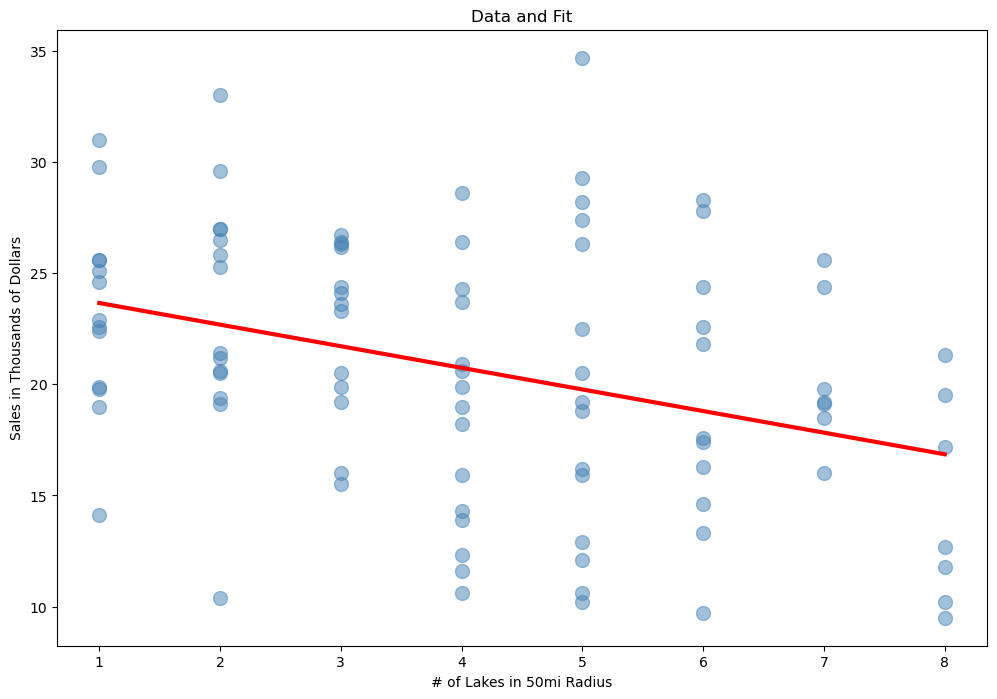

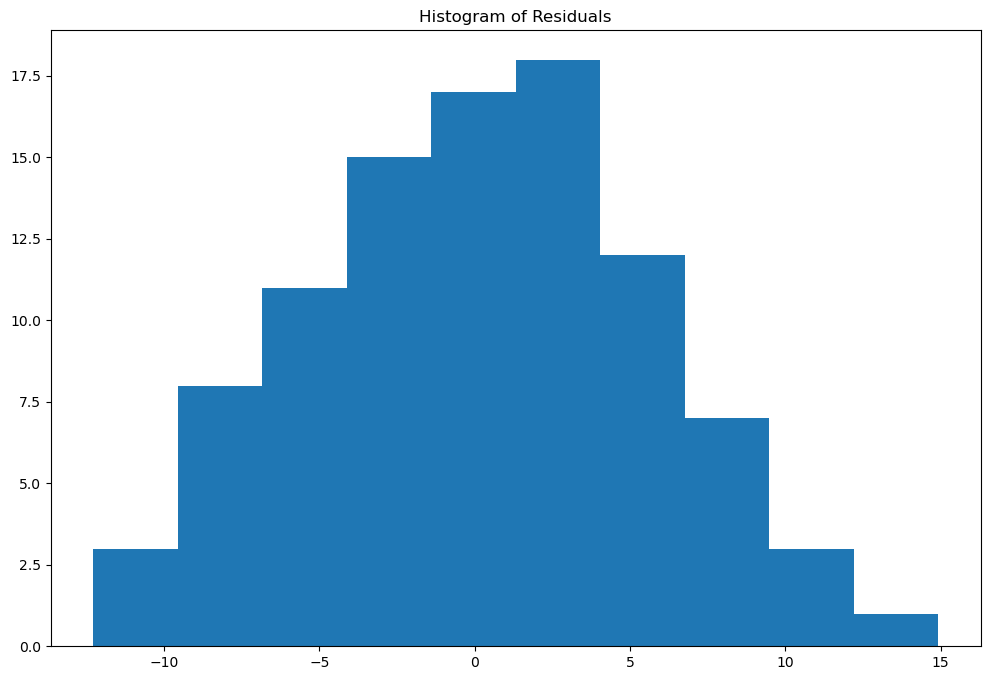

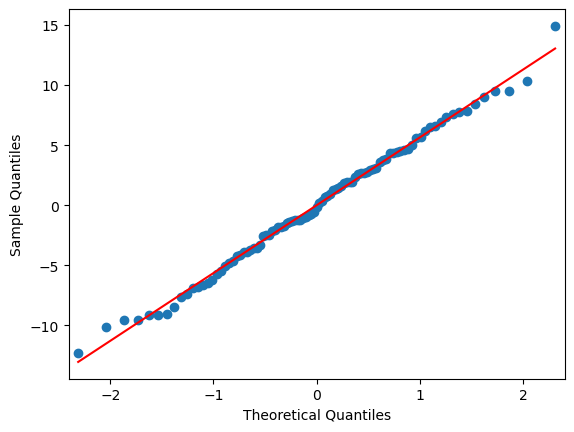

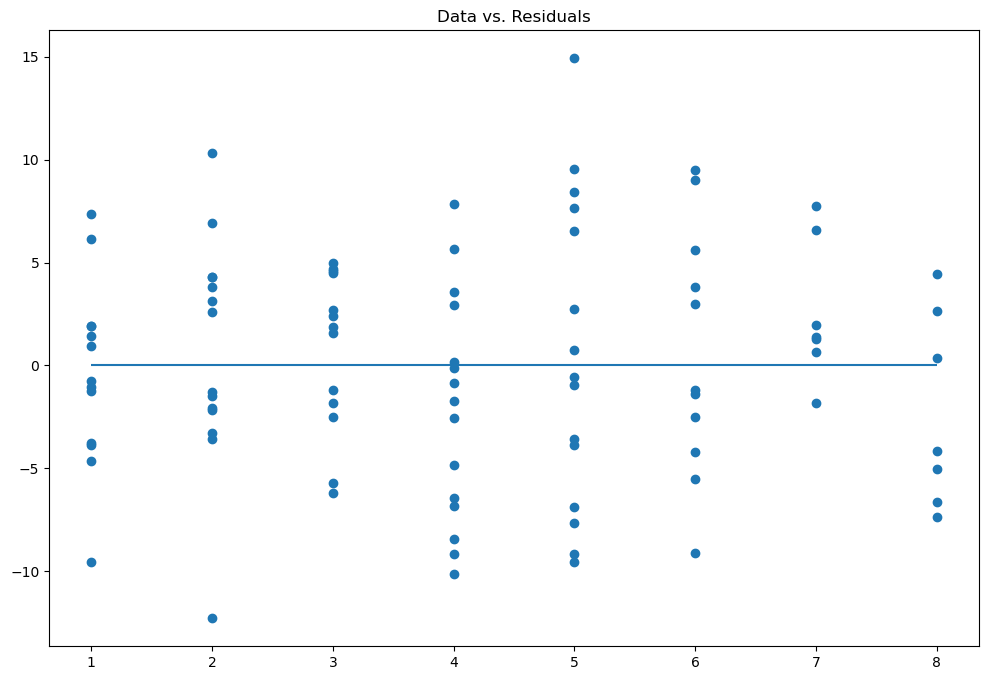

In [4]:
fig, ax= plt.subplots(figsize=(12,8))

#scatter plot of data and slr line
ax.scatter(dfPad['lakes'], dfPad['sales'],color="steelblue", alpha=0.5, s=100)
ax.plot( dfPad['lakes'], slr.fittedvalues,color='red',lw=3)
ax.set_xlabel('# of Lakes in 50mi Radius')
ax.set_ylabel('Sales in Thousands of Dollars')
ax.set_title('Data and Fit')

#Frequency histogram of residuals of SLR model
fig, ax= plt.subplots(figsize=(12,8))

ax.hist(slr.resid)
ax.set_title('Histogram of Residuals')

#Q-Q plot of residuals
print(sm.qqplot(slr.resid,line='q'))

#Scatter plot of data vs residuals
fig, ax= plt.subplots(figsize=(12,8))

ax.scatter(dfPad['lakes'], slr.resid)
ax.set_title('Data vs. Residuals')
ax.hlines(0, xmin=np.min(dfPad['lakes']), xmax=np.max(dfPad['lakes']))

plt.show()

 - ***(1A iii). (2 points) Does this model seem appropriate?  For each of the 4 major assumptions of a simple linear regression model, use your plots in part (ii) to decide whether or not the dataset meets those assumptions.***



The data appears to have a statistically significant linear relationship as the first scatter plot clearly shows the means at each point follow a negatively sloped linear pattern

The data also has independent errors as seen by the last scatter plot graph which has as best fit line with a slope of 0, indicating there is no statistically significant linear relationship between the errors

The errors is normally distributed as seen by the second graph of the histogram, which can visually be seen that the errors are normally distributed or by looking at the q-q plot and seeing the errors follow the best fit line closely in the majority of the graph

The variance in errors appears to be equal as seen by the last graph, where the points can be obsersed to be spread from the best fit line appromaxiately equal at each data point

 - ***(1A iv) (1 pt) What is the meaning of the slope in the model in terms of the variables in the dataset?  Based on the physical meaning of the variables, does the value of this slope seem reasonable or does it surprise you?  Explain.***


The value of the slope is by how much sales will increase by with depending on the number of $x$ lakes in a 50mi radius of the shop. The value of the slope does seem reasonable to be because I believe it would make more sense for a shop in range of two lakes to have greater sales than a shop within range of one. Some people may expect sales to double with an additional lake, but it is also likely more competition will be present the more lakes your shops in range of explainig the 1.224 slope value. 

- ***(1A v) (1 pt) Using the summary output from your model, what percent of total variation in sales revenue can be explained by the number of nearby lakes/reservoirs? Explain.***

In [5]:
slr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     13.20
Date:                Tue, 02 May 2023   Prob (F-statistic):           0.000459
Time:                        04:37:34   Log-Likelihood:                -295.44
No. Observations:                  95   AIC:                             594.9
Df Residuals:                      93   BIC:                             600.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.6338      1.224     20.120      0.000      22.203      27.065
lakes         -0.9723      0.268     -3.633      0.000      -1.504      -0.441
==============================================================================
Omnibus:                        0.536   Durbin-Watson:                   0.905
Prob(Omnibus):                  0.765   Jarque-Bera (JB):                0.662
Skew:                           0.046   Prob(JB):                        0.718
Kurtosis:                       2.602   Cond. No.                         10.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Using the $R^2$ it appears that only $12.4$% of the sales can be explained by the nearby lakes and reservoirs since $R^2$ measures the errors present in the model

(inadvertently skipped labeling from A to C...oh well!)

### [1] Part C: Statistical Inference Using your Model  (7 pts)
***Your friend would like to know if there's sufficient evidence from this model to conclude that the number of nearby lakes/reservoirs is a statistically significant linear predictor of sales revenue.  You decide to do a hypothesis test at the  $\alpha = 0.05$ significance level.***

- ***(1C i). (1 points)  State the null and alternate hypotheses for your test.***


$H_0: \beta = 0$

$H_A: \beta \neq 0$

 - ***(1C ii). (2 points) Using the summary output from your model, what is the conclusion of your test?  Explain what output you used (i.e. exactly what part of the table did you use)  and justify your answer.***


Based on the summary output will we reject the null hypothesis and accept the alternative claiming # of lakes is a linear predictor of sales because first the $p-value= 0.000 < \alpha = 0.05$. Additionally, $0$ is not contained within the confidence interval $[-1.504, -0.441]$ indicating the we should reject the null.



 - ***(1C iii) (2 pts)  Your friend is considering opening another shop in a new location with 5 nearby lakes.  What is the $90\%$ prediction interval for the annual sales revenue for a shop with 5 nearby lakes?  Your friend has not taken statistics before, so interpret what this means in words your friend can understand.***  



In [6]:
predictions = slr.get_prediction(np.array([1,5]))
predictions.summary_frame(alpha=0.1)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,19.772263,0.615846,18.749095,20.795432,10.606334,28.938192


For a shop in range of 5 lakes the anual sales 90% prediction interval is $[610.606, 28.938]$


 - ***(1C iv)  (2 pts) Create one plot with the original data, the model, and the $90\%$ prediction and confidence bands for the model***




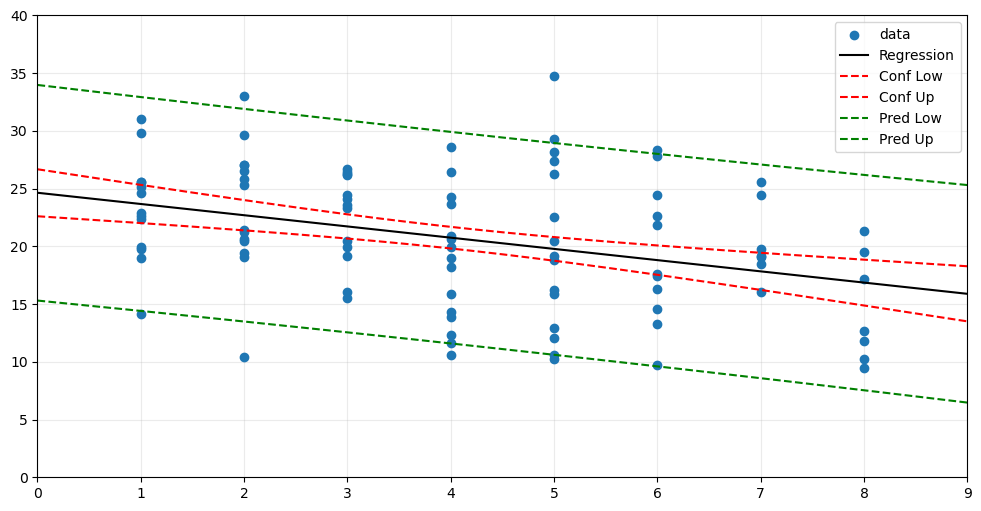

In [7]:
#Create Prediction and Confidence Bands

# Inspect the results
xgrd=np.linspace(0,150,1000) #grid for plotting
#find confidence and predictive intervals all over our plot:

predictions = slr.get_prediction(sm.add_constant(xgrd))
predmat = predictions.summary_frame(alpha=0.1)


#plot it all
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim([0,9])
ax.set_ylim([0,40])
plt.scatter(dfPad['lakes'], dfPad['sales'], label='data')

#Plot each column
plt.plot(xgrd,(predmat.mean_ci_lower+predmat.mean_ci_upper)/2, color='black', label='Regression')
plt.plot(xgrd,predmat.mean_ci_lower, 'r--', label='Conf Low')
plt.plot(xgrd,predmat.mean_ci_upper, 'r--', label='Conf Up')
plt.plot(xgrd,predmat.obs_ci_lower, 'g--', label='Pred Low')
plt.plot(xgrd,predmat.obs_ci_upper, 'g--', label='Pred Up')

plt.legend()
plt.show()

<a id='p2'></a>
#  Problem 2: Go Big-  Multiple Linear Regression (35 pts)

***


You feel unsatisfied with the results from the model in Problem 1.    

Problem 2 will involve steps to improve your model from Problem 1 using Multiple Linear Regression (MLR).  

We will continue working with the same dataset from Problem 1 (paddle.csv) throughout this problem.



In an effort to improve the model from Problem 1, you decide to add in one additional predictor.  To determine which predictor to add next you start with some scatterplots of the dataset.  


### [2] Part A:  Explore (5 pts)

 - ***(2A i). (1 point) Use the function `seaborn.pairplot` to create pairwise scatterplots of the continuous predictors/covariates in the paddle.csv data, both against each other and against the outcome (sales). https://seaborn.pydata.org/generated/seaborn.pairplot.html***

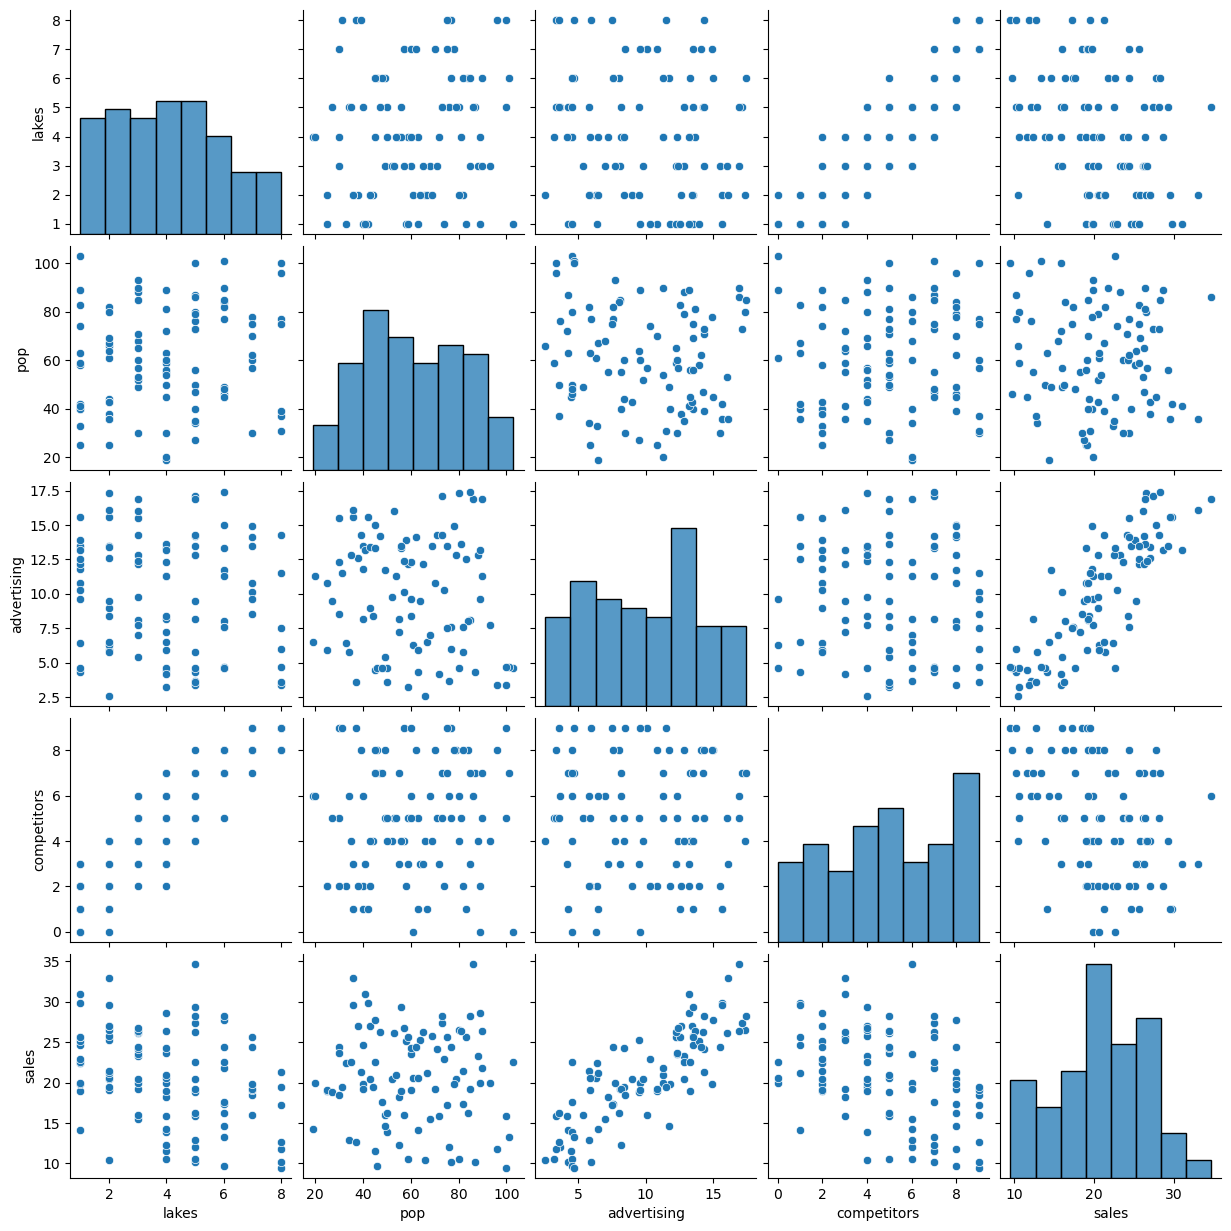

In [8]:
seaborn.pairplot(dfPad)

 - ***(2A ii). (2 points)  Based on your scatterplots, which (if any) explanatory variable(s) appear to have a linear relationship with sales revenue?  Explain.***     

Based on a visual examination of the scatters plots it appears that lakes, advertising, and competitors appear to have a linear relationsip with sales with some having stronger relationship than others. For lakes a mild linear relationship can be seen as the number of lakes near by increases it seems sales decrease. The more advertising the more sales, which is clearly seen in the scatter plot. Finally the more competitors the lower sales become based on the downward trend in the data.


 - ***(2A iii). (2 points)  Print the correlation matrix.  Are any of the ****explanatory**** variables strongly correlated with one another?  If so, which ones?***

In [9]:
dfPad[["lakes", "pop", "advertising", "competitors"]].corr()

,lakes,pop,advertising,competitors
lakes,1.000000,0.138156,-0.128524,0.895413
pop,0.138156,1.000000,-0.114839,0.080539
advertising,-0.128524,-0.114839,1.000000,-0.079184
competitors,0.895413,0.080539,-0.079184,1.000000


It appears lakes and competitors have a high correlation of $89.5$%

### [2] Part B: Adjust the Model (5 pts)

***(2B i).  (1 pt) Choose one additional explanatory variable to add to your model, based on your exploratory analysis in Part 2A.  Explain your reasoning for the variable you have chosen.***



I am choosing to add advertising because it clearly has a significant linear relationship with sales. Additionally, I am not including population because it does not appear to have a significant linear relationship with sales, and I am not including competitors because it has a high correlation with the already included predictor number of lakes.

***(2B ii). (2 points) Create a Multiple Linear Regression Model with `sales` as the dependent variable, `lakes` as one of the independent variables and the new variable you have chosen as the other independent variable.***  

***Print the model output summary table for this new model, and then write the equation for this new model in a markdown cell.***

In [10]:
# Collect the features in a 2D array 
X = dfPad[["lakes", "advertising"]]

# Add a constant to the array for the intecept 
X = sm.add_constant(X)

# Collect the response data in an array 
y = dfPad["sales"]

# Fit the ordinary least-squares (OLS) model 
mlr = sm.OLS(y, X).fit()

mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     132.4
Date:                Tue, 02 May 2023   Prob (F-statistic):           8.31e-28
Time:                        04:37:38   Log-Likelihood:                -237.35
No. Observations:                  95   AIC:                             480.7
Df Residuals:                      92   BIC:                             488.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          12.4814      1.056     11.816      0.000      10.383      14.579
lakes          -0.6913      0.147     -4.696      0.000      -0.984      -0.399
advertising     1.1101      0.075     14.849      0.000       0.962       1.259
==============================================================================
Omnibus:                        0.577   Durbin-Watson:                   1.607
Prob(Omnibus):                  0.749   Jarque-Bera (JB):                0.710
Skew:                           0.158   Prob(JB):                        0.701
Kurtosis:                       2.718   Cond. No.                         39.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

MLR formula is $Y = 12.481 - (0.6913)x_{lakes} + (1.1101)x_{ads}$

***(2B iii). (2 points) Create a 3D plot of your data AND your model (i.e. you should have a plane that represents your model and a scatter plot that represents your data). Label your axes.***

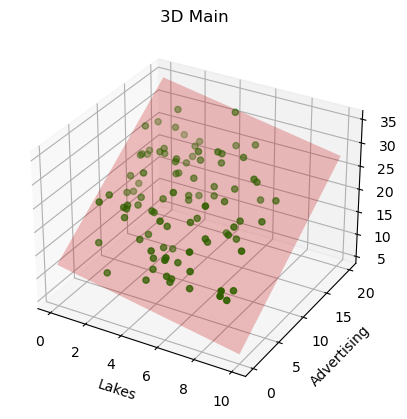

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = Axes3D(fig)
ax=plt.axes(projection = '3d')
 
# creating the plot
plot_geeks = ax.scatter(dfPad['lakes'], dfPad['advertising'],dfPad['sales'],  c = "g")
 
# setting title and labels
ax.set_title("3D plot")
ax.set_xlabel('Lakes')
ax.set_ylabel('Advertising')
ax.set_zlabel('Sales')
plt.title("3D Main")
 
x = np.linspace(0, 10, 100)
y = np.linspace(0, 20, 100)

x, y = np.meshgrid(x, y)

#Enter the linear model equation here:
eq = (-.6913 * x) + (1.1101 * y) + 12.481277


ax.plot_surface(x, y, eq, color='red', alpha=0.25)

# displaying the plot
plt.show()

### [2] Part C: Inference on MLR Model: Step 1 ( 7 pts)

Let's check that this model meets the assumptions for multiple linear regression.  

***(2C i) Make the following 4 plots (2 pts):***

 -  A histogram of *residuals* of best least-squares fit.

 -  A Q-Q plot of *residuals*, comparing to a normal distribution.

 -   A scatter plot where the `lake` data values are the x-axis and the *residuals* are the y-axis.

 -  A scatter plot where the $x$-axis is the data for the other variable you chose to include in the model and *residuals* are the y-axis.




Text(0.5, 1.0, 'Advertising vs Residuals')

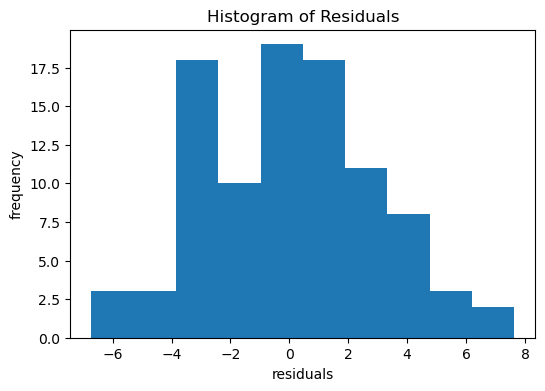

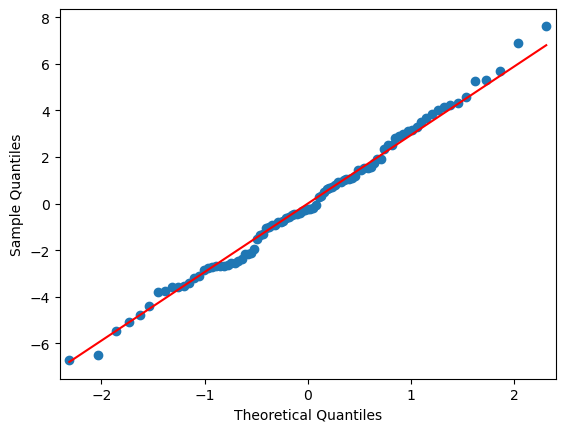

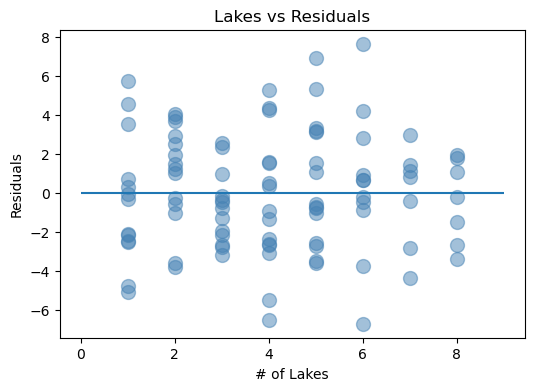

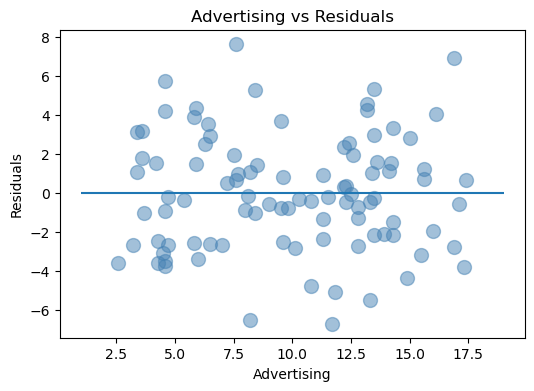

In [12]:

#Frequency histogram of residuals of SLR model
fig, ax= plt.subplots(figsize=(6,4), ncols=1)
ax.hist(mlr.resid)

ax.set_title('Histogram of Residuals')
ax.set_xlabel("residuals")
ax.set_ylabel("frequency")

#Q-Q plot of residuals
sm.qqplot(mlr.resid, line='s');

#scatter plot of lakes data vs residuals
fig, ax= plt.subplots(figsize=(6,4))
ax.scatter(dfPad['lakes'], mlr.resid, color="steelblue", alpha=0.5, s=100)
ax.hlines(0, 0 , 9)
ax.set_xlabel('# of Lakes')
ax.set_ylabel('Residuals')
ax.set_title('Lakes vs Residuals')

#Scatter plot of ads vs residuals
fig, ax= plt.subplots(figsize=(6,4))
ax.scatter(dfPad['advertising'], mlr.resid, color="steelblue", alpha=0.5, s=100)
ax.hlines(0, 1 , 19)
ax.set_xlabel('Advertising')
ax.set_ylabel('Residuals')
ax.set_title('Advertising vs Residuals')

***2C ii). (2 pts)   What are the major assumptions of a multiple linear regression model?  For each of these assumptions, use your plots above to decide whether or not the data set meets those assumptions. Explain your reasoning.***

1) The first assumption about the MLR is the mean response, $E(Y_i)$, at each set of values of the predictors have a linear relationship/function. This is confirmed by looking at the histogram of the residuals, and since the histogram is centered around zero our model meets this assumption.

2) The second assumption about the MLR is errors are Independent, which can be seen by looking at the 'lakes vs residuals' and 'advertising vs residuals'. In both graphs it appears the points bounce randomly around the zero slope line showing no noticeable linear relationships in their errors.

3) The third assumption about the MLR is errors at each set of values of the predictors are normally distributed, which can be seen in both the histogram graph of the residuals which shows an approximately normal distribution around 0 and the q-q plot which also shows the data plots approximately following the best fit line.

4) The fourth assumption about the MLR is errors at each set of values of the predictors have equal variances, which can be seen on the the 'lakes vs residuals' and 'advertising vs residuals' graphs. In both graphs we can see the values stay approximately within the same range across the entire graph, with no signs of the data's range funneling in or spreading out on either side

***Let's see if this new model as a whole is significant at an alpha level of  5%.  In other words, we want to use a single test to see if at least one of the two explanatory variables really has a significant linear association with the response variable.***  

 - ***(2C iii). (1 point)  State the null and alternate hypotheses we should test at an alpha level of  5% , and explain what they mean in a sentence.***
 

$H_0: \beta_0 \text{ and } \beta_1 = 0$ which means there are not linear relationships between the explanatory variables and the response variable

$H_A: \beta_0 \text{ and } \beta_1 \neq 0$ which means linear relationships exists between the explanatory variables and the response variable

 - ***(2C iv). (2 points) Use the output of your model to determine the conclusion of this test. Explain what output you used.***

In [13]:
mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     132.4
Date:                Tue, 02 May 2023   Prob (F-statistic):           8.31e-28
Time:                        04:37:39   Log-Likelihood:                -237.35
No. Observations:                  95   AIC:                             480.7
Df Residuals:                      92   BIC:                             488.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          12.4814      1.056     11.816      0.000      10.383      14.579
lakes          -0.6913      0.147     -4.696      0.000      -0.984      -0.399
advertising     1.1101      0.075     14.849      0.000       0.962       1.259
==============================================================================
Omnibus:                        0.577   Durbin-Watson:                   1.607
Prob(Omnibus):                  0.749   Jarque-Bera (JB):                0.710
Skew:                           0.158   Prob(JB):                        0.701
Kurtosis:                       2.718   Cond. No.                         39.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Based on the facts:
1) p-value of $0.000$ is less than $\alpha = 0.05$
2) the confidence interval, $CI = [10.383, 14.579]$, does not contain zero

Therefore we can reject the null hypothesis and accept the alternative that the two explanatory variables have a significant linear association with the response variable.

### [2] Part D: Inference on MLR Model: Step 2 (4 pts)

After Part 2C, you should have found that the new model as a whole is significant. So, it will be helpful to know exactly which variable (or variables) have a significant linear association with the response variable.  

 - ***(2Di). (2 points) This will require multiple tests.  State the null and alternate hypotheses we should test at an alpha level of  5% , and explain what they mean in a sentence.***






Test of Lakes vs Sales:

$H_0: \beta_{lake} = 0$ which means there is not linear relationship between the lakes variable and sales

$H_A: \beta_{lake} \neq 0$ which means a linear relationship exists between the lakes variable and sales

Test of Advertising vs Sales:

$H_0: \beta_{ads} = 0$ which means there is not linear relationship between the adsvertising variable and sales

$H_A: \beta_{ads} \neq 0$ which means a linear relationship exists between the adsvertising variable and sales

 - ***(2Dii). (2 points) Explain the conclusion(s) of these tests for each of the explanatory variables in your model, using output from your model summary table.
(Note: For this part of the problem you do not need to calculate each test statistic from scratch- instead you can just look up the appropriate results from the output summary table and explain your conclusions below).***


For lakes we can draw the facts from the summary table:
1) p-value of $0.000$ is less than $\alpha = 0.05$
2) the confidence interval, $CI = [-0.984, -0.399]$, does not contain zero

Therefore we can reject the null hypothesis and accept the alternative that a linear relationship exists between the lakes variable and sales.

For advertising we can draw the facts from the summary table:
1) p-value of $0.000$ is less than $\alpha = 0.05$
2) the confidence interval, $CI = [0.962, 1.259]$, does not contain zero

Therefore we can reject the null hypothesis and accept the alternative that a linear relationship exists between the adsvertising variable and sales.

### [2] Part E: Quantifying Model Goodness of Fit (3 pts)

***In general, adding more variables to our model will increase the percent of total variation in the dependent variable that can be explained with the model.  However this comes at a cost.  
(2E i)  (2 pts) What is at least one potential problem with using all the explanatory variables available in your dataset to fit a model?***

If we include all of our explanatory variables we may end up inflating the $R^2$ value as the $R^2$ value will simply increase the more variation the model has without concern of the number of variables

**(2E ii). (1 pt)  What is the name of the metric that measures how much total variation is explained by our model but adds a penalty to this number for adding additional variables that don't imporve the model?     Use your summary model output to find the value of this metric for your new model.  Is this an improvement compared to your answer from Part (1A v)?***


The metric that measures the total varation for an MLR is $Adjusted \space R^2$, which from out summary table is $Adj. \space R^2 = 0.737$. 

Comparing this to problem 1Av's value $R^2 = 0.124$ it would appear as an improvement because the $Adj. \space R^2  = 0.737$ is much closer to $1$.

### [2] Part F: Final Pass at a Model  (6 pts)


You are curious if the model you found above is really the best you can do with the dataset.  

In this open-ended problem you will use the same dataset (paddle.csv) but you may use any subset of the columns to build your "best" Multiple Linear Regression model.  i.e. you want to create the best model you can to quantify how sales can be explained and predicted by the features in this dataset.

For this problem the dependent variable will still be sales.  Any other variables will be candidates for explanatory variables.  


Your goal is to demonstrate that you have an understanding of how to choose between columns and validate/check for issues in a multiple linear regression problem.

 - ***(2F i). (4 pts)  By adding variables step-by-step to a minimal model or by removing variables step-by-step from the full model, use one or more of the criteria covered in our class to create a reasonable candidate model (i.e. the "best" you can do with the data given). The criteria you use may include (but are not limited to):***
 
  - ***adjusted $R^2$***
  - ***inclusion/removal of most or least-significant t-tests on coefficients***
  - ***F-tests to compare between models***
  - ***Comparison of AIC between models***
  
 
***In addition to code showing the model variations you try, use markdown cell(s) to write-up an explanation of your reasoning for each step of this process as you construct a final version of the model.***

***Your explanation should include the results (from the output summary) of the F-test and t-tests for your final model. If you choose to include an insignificant explanatory variable in your final model you must fully justify your reasoning.*** 

  


In [14]:
print(dfPad[["lakes", "pop", "advertising", "competitors"]].corr())
print()

# Collect the features in a 2D array 
X = dfPad[["competitors", "advertising"]]

# Add a constant to the array for the intecept 
X = sm.add_constant(X)

# Collect the response data in an array 
y = dfPad["sales"]

# Fit the ordinary least-squares (OLS) model 
mlr = sm.OLS(y, X).fit()

mlr.summary()

                lakes       pop  advertising  competitors
lakes        1.000000  0.138156    -0.128524     0.895413
pop          0.138156  1.000000    -0.114839     0.080539
advertising -0.128524 -0.114839     1.000000    -0.079184
competitors  0.895413  0.080539    -0.079184     1.000000



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     161.4
Date:                Tue, 02 May 2023   Prob (F-statistic):           8.24e-31
Time:                        04:37:39   Log-Likelihood:                -230.21
No. Observations:                  95   AIC:                             466.4
Df Residuals:                      92   BIC:                             474.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          13.1652      0.964     13.658      0.000      11.251      15.080
competitors    -0.7267      0.114     -6.368      0.000      -0.953      -0.500
advertising     1.1204      0.069     16.242      0.000       0.983       1.257
==============================================================================
Omnibus:                        0.286   Durbin-Watson:                   1.585
Prob(Omnibus):                  0.867   Jarque-Bera (JB):                0.426
Skew:                           0.112   Prob(JB):                        0.808
Kurtosis:                       2.761   Cond. No.                         40.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

I include competitors and advertising because:

1) They are explanatory variables witht the strongest linear relationships with sales making them the most significant

2) Removing lakes becauses although somewhat significant it has a high correlation with competitors, but of the two competitors has a stronger linear relationship with sales

3) Removing population because it has a weak linear relationship with sales and is an insignificant variable

Since the $Prob(F-statistic)_{new} = 8.24e^{-31}$ is less than the previous models $Prob(F-statistic)_{old} = 8.31e^{-28}$ therefore the new model has slightly better p-values. Additionally the model I used has a $t-score_{new} = 13.658$ which is greater than the $t-score_{old} = 11.816$ indicating the a larger difference exists between the two sample sets than in the original allowing for greater variation. On top of this the $Adj. \space R^2_{new} = 0.773$ is higher than  $Adj. \space R^2_{old} = 0.737$ indicating we have a better total variation than the last model. Finally, the $AIC_{new} = 466.4$ and $BIC_{new} = 474.1$ are lower than in the old model which had an $AIC_{old} = 480.7$ and a $BIC_{old} = 488.4$, indicating the newer model has a better fit.

 - ***(2F ii).  (2 pts) Give the equation for your final model (in markdown) AND interpret the meaning of the intercept and coefficients in your final model in the context of the problem.   Explain how your final model makes sense in the context of the problem (or if it doesn't, you'll want to try to explain why not).*** 

$Y = 13.1652 + (-0.7267 * x_{competitors}) + (1.1204 * x_{ads})$

The $y-intercept$ in this model indicates what the expected sales of a shop will be if there are zero competitors and they use zero advertising, this makes sense because it is relatively close to the other models $y-intercept = 12.48$.

The first coefficient for competitors indicates the rate at which sales will decrease as the number of competitors in the area increase, which makes sense because as the number of competitors increase some of the customers will be drawn away to their shops.

The second coefficient for advertising indicates the rate at which sales will increase as the shop increases their amount of advertising, which makes sense because the more a shop typically sends on advertising the more people will know about the shop and the more interested they will be in shopping there.

Overall the model makes sense because the more competitors you have the more you will lose in sales explaining the negative coefficient, but customers can easily be attrached with ads causing sales to have a positive coefficient.


### [2] Part G: Back To Your Friend (5 pts)

After finishing your final model, you report the results to your friend.  Your friend asks you to answer the following questions:  
 
 
 - ***2G i). (2 pt) Provide 95% confidence intervals for each of the coefficients in your final model from Part F (you can use the summary table to find these and you do not need to provide a confidence interval for the intercept).  Since your friend is rusty at statistics, write an explanation/ interpretation of what each of the confidence intervals mean in the context of this dataset.*** 
 

For the competitors varaible the $95$% $CI = [-0.953, -0.500]$, which since it does not contain zero indicates it is highly likely that the number of competitors affects the sales of a shop as these two values have a linear relationship

For advertising variable the $95$% $CI = [0.983, 1.257]$, which also does not contain zero indicating it is highly likely that there is a linearly realtionship between advertising and sales

 - 2Gii). ***(2 pts) Your friend is thinking of opening a new paddleboard shop in a town with population density of 75 people per square mile.  The town has 4 lakes nearby and currently only 2 nearby competitors. Use your model from Part F to give a $95\%$ prediction interval for the expected first year sales revenue at this new store if they spend $\$8000$ on advertising in the first year.*** 

In [15]:
predictions = mlr.get_prediction(np.array([4, 2, 8000]))

predictions.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,9014.42547,548.97271,7924.118283,10104.732657,7924.104361,10104.746579


The $95$% prediction interval for first year sales is $[7924.11, 10104.75]$ or between $\$7924.11$ and $\$10,104.75$

- ***2Giii). (1 pt) Is there any other data (i.e. other possible explanatory variables) you recommend your friend gather in the future to possibly improve the model of sales revenue?  Explain.***  

In the future there are many other explanatory variables my friend could collect, such as how climate/weather which may affect peoples choice on whether they want to paddle board on a particular lake, location relatively to transportation as people may not come if it is difficult to get to a particular lake, or dangerous animals in the lake which may discourage people from paddle baording in them.

#### Selected Answers:

1C i).  12.4

1C iii). $[10.606, 28.938]$ in thousands of dollars.